# 00 · The whole project in one notebook

**The question.** You have many short pieces of data (*windows*): a day of
traffic, six hours of a wind turbine, one heartbeat. Each window was made by
one of a few hidden **rules**, closed-form laws like $y = x^2 + x$. Nobody tells
you which rule made which window. Can you find **both**: the rules, and which
window came from which rule?

**How to read this notebook.** Every figure comes with three short notes:
- **The task**: the question the figure answers;
- **What you see**: how to read it;
- **Take-away**: what it means.

The plotting code lives in `notebooks/summary_figs.py`, so each cell here is
one line. Numbers, seeds and statistical details are in `RESULTS.md`; the
algorithm is built by hand in `09_algorithm_tutorial`.

| part | what you get |
|---|---|
| 1 · Motivation | why group windows by their law, not by how they look |
| 2 · The method | the idea, what laws are built from, the objective |
| 3 · A worked example | the method run live, step by step |
| 4 · What works | the main results |
| 5 · Real data | two years of bike-sharing days, on a calendar |
| 6 · What did not work | three failures, and what they teach |
| 7 · Every task in one picture | all sixteen questions, answered |

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))
%matplotlib inline
from lrdsr import viz
viz.style()
from notebooks import summary_figs as S

---
# 1 · Motivation: looking alike is not the same law

**The task.** The usual way to group windows is to compute a few statistics
of each one (mean, trend, …) and cluster those. Does that find windows made by
the same rule?

**What you see.**
- **Left:** four windows, as you would get them.
- **Middle:** the truth. Windows 1 and 2 come from a parabola, windows 3 and 4 from a straight line.
- **Right:** the statistics a usual clustering would compare.

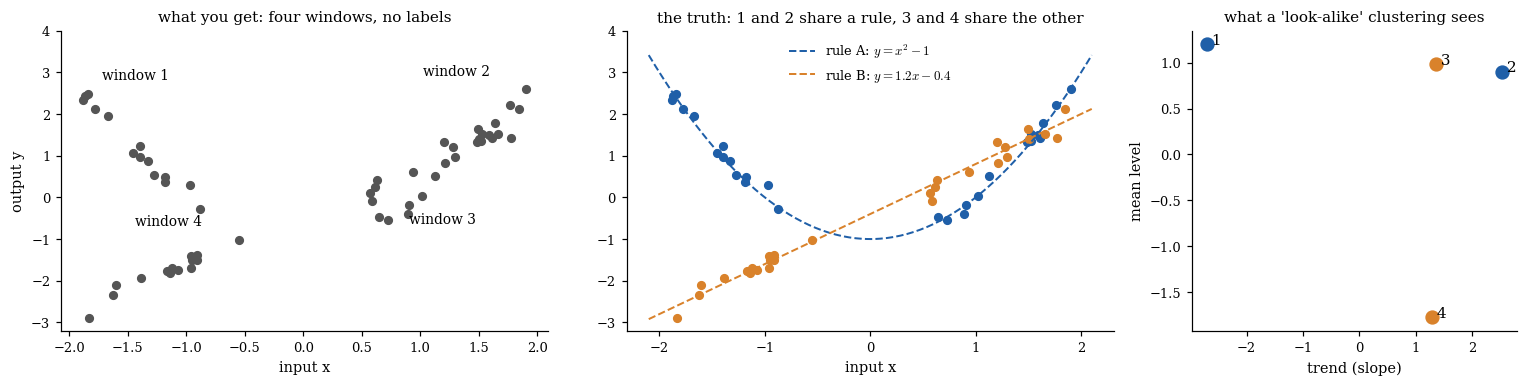

In [2]:
S.motivation()

**Take-away.** On the right, window 2 sits next to window 3, a *different*
rule, and far from its true partner, window 1. Windows 1 and 2 look nothing
alike because they saw different inputs. The only thing they share is the
**equation** that made them. So this project groups windows by their law, and
returns that law as a readable formula.

---
# 2 · The method

**The idea in one picture.** Windows go in. The method alternates two
questions until the answers stop changing: *what is each law?* and *which
law made each window?* Labels and formulas come out.

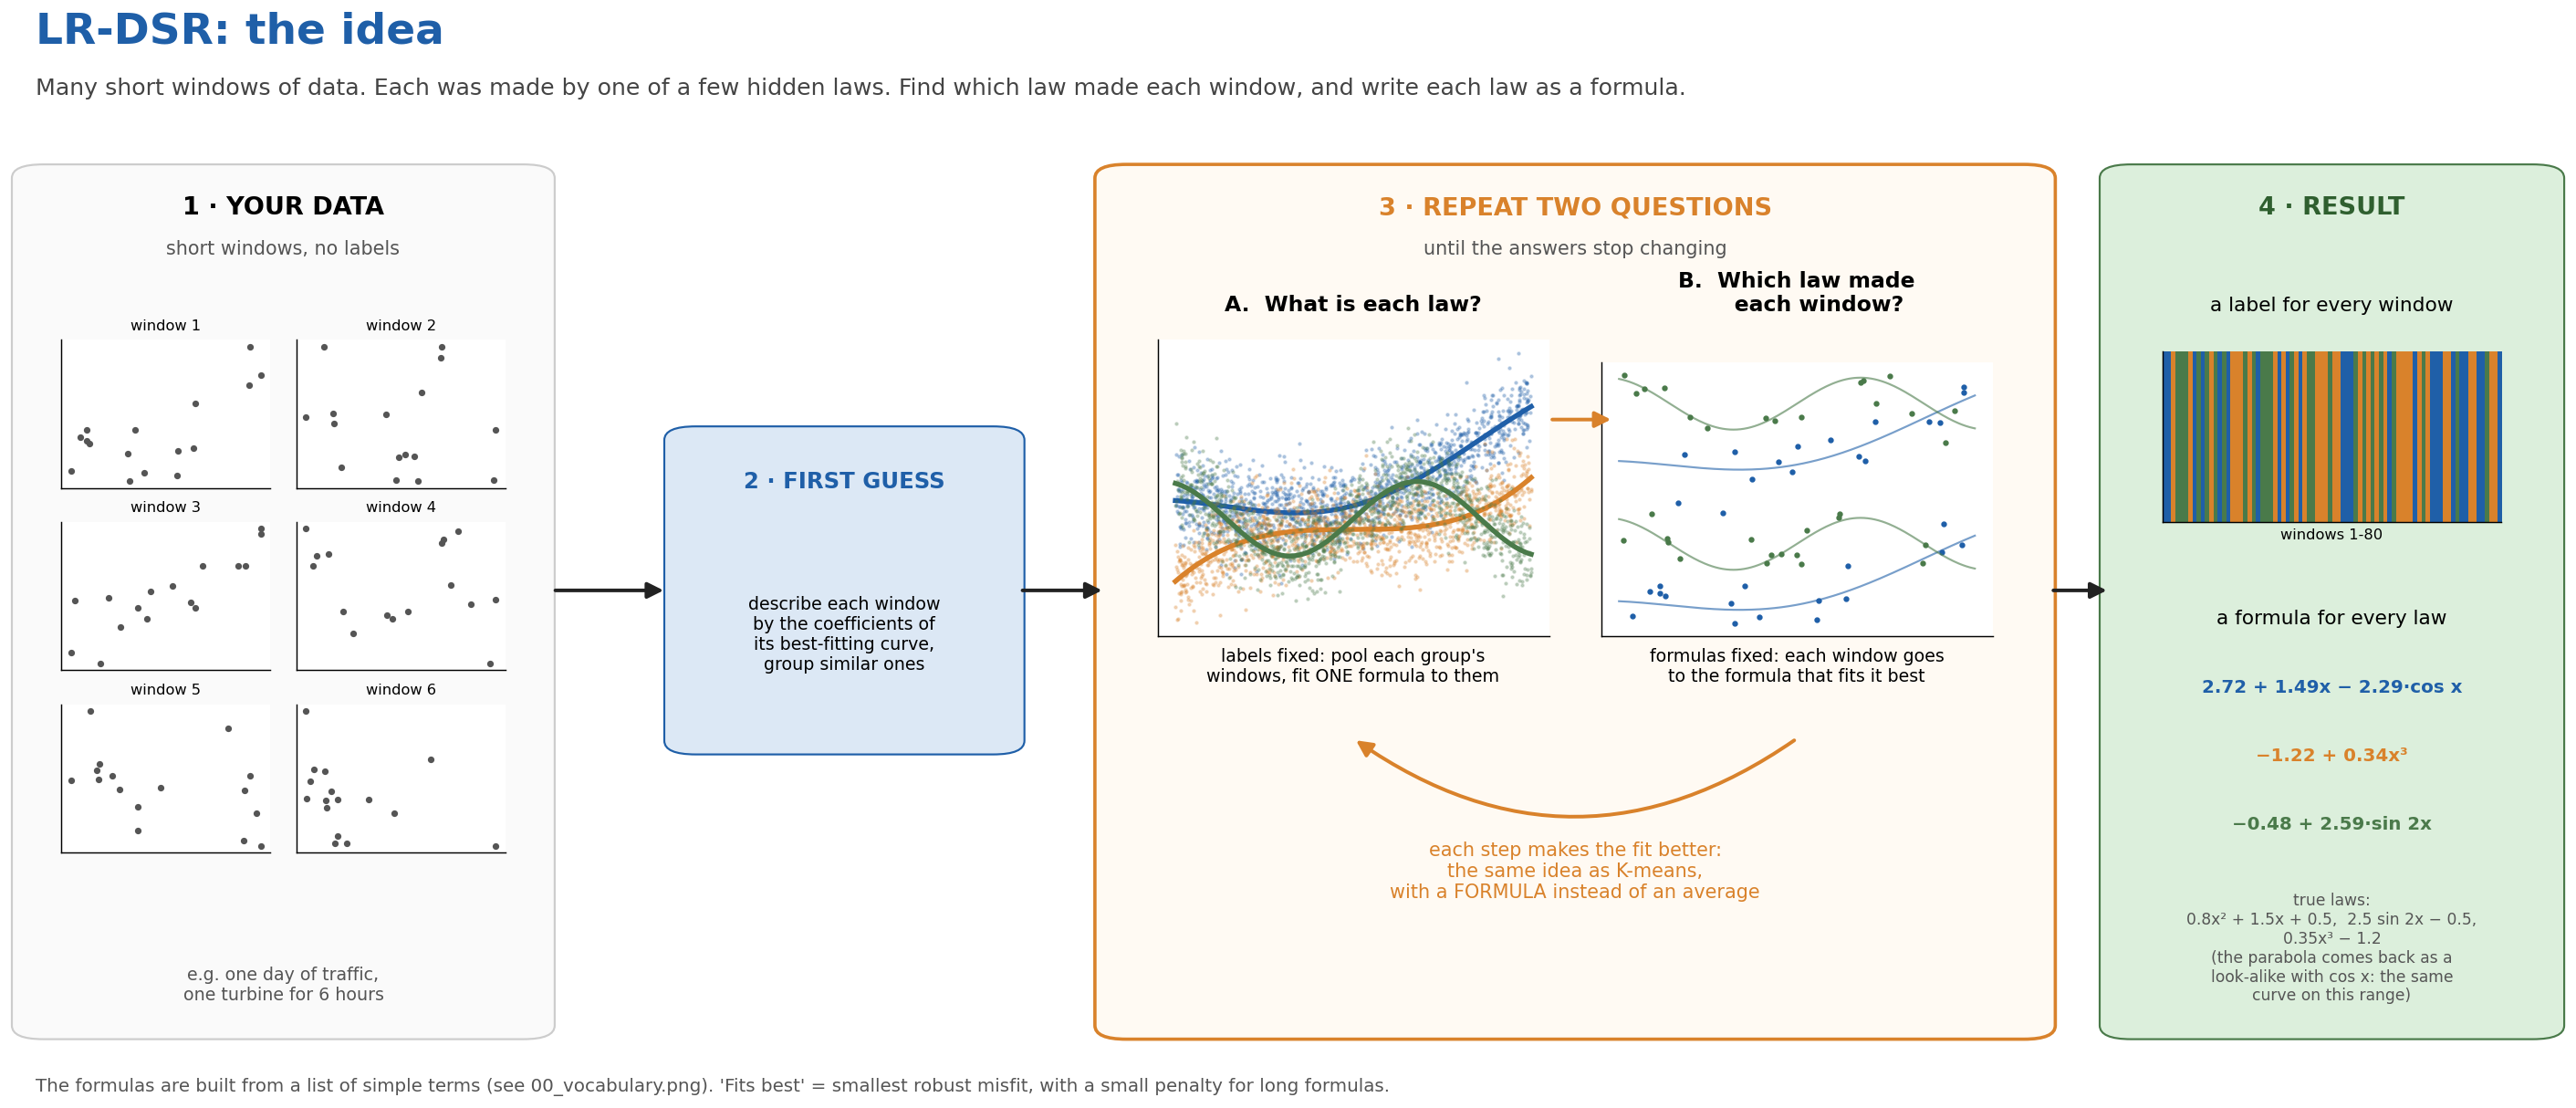

In [3]:
S.show("00_the_idea.png")

**What a law is built from.** A law is a short sum of simple **terms**.
- **A · Fixed terms**: the default library.
- **B · Terms with a number fitted inside**, like $\sin(a\,x)$: a trial option.
- **C · Open-ended search** (PySR): optional, once at the end.

The ladder at the bottom goes from "know nothing" to the **oracle**, which
knows every law exactly. The oracle is not a method; it is the yardstick for
the best possible result.

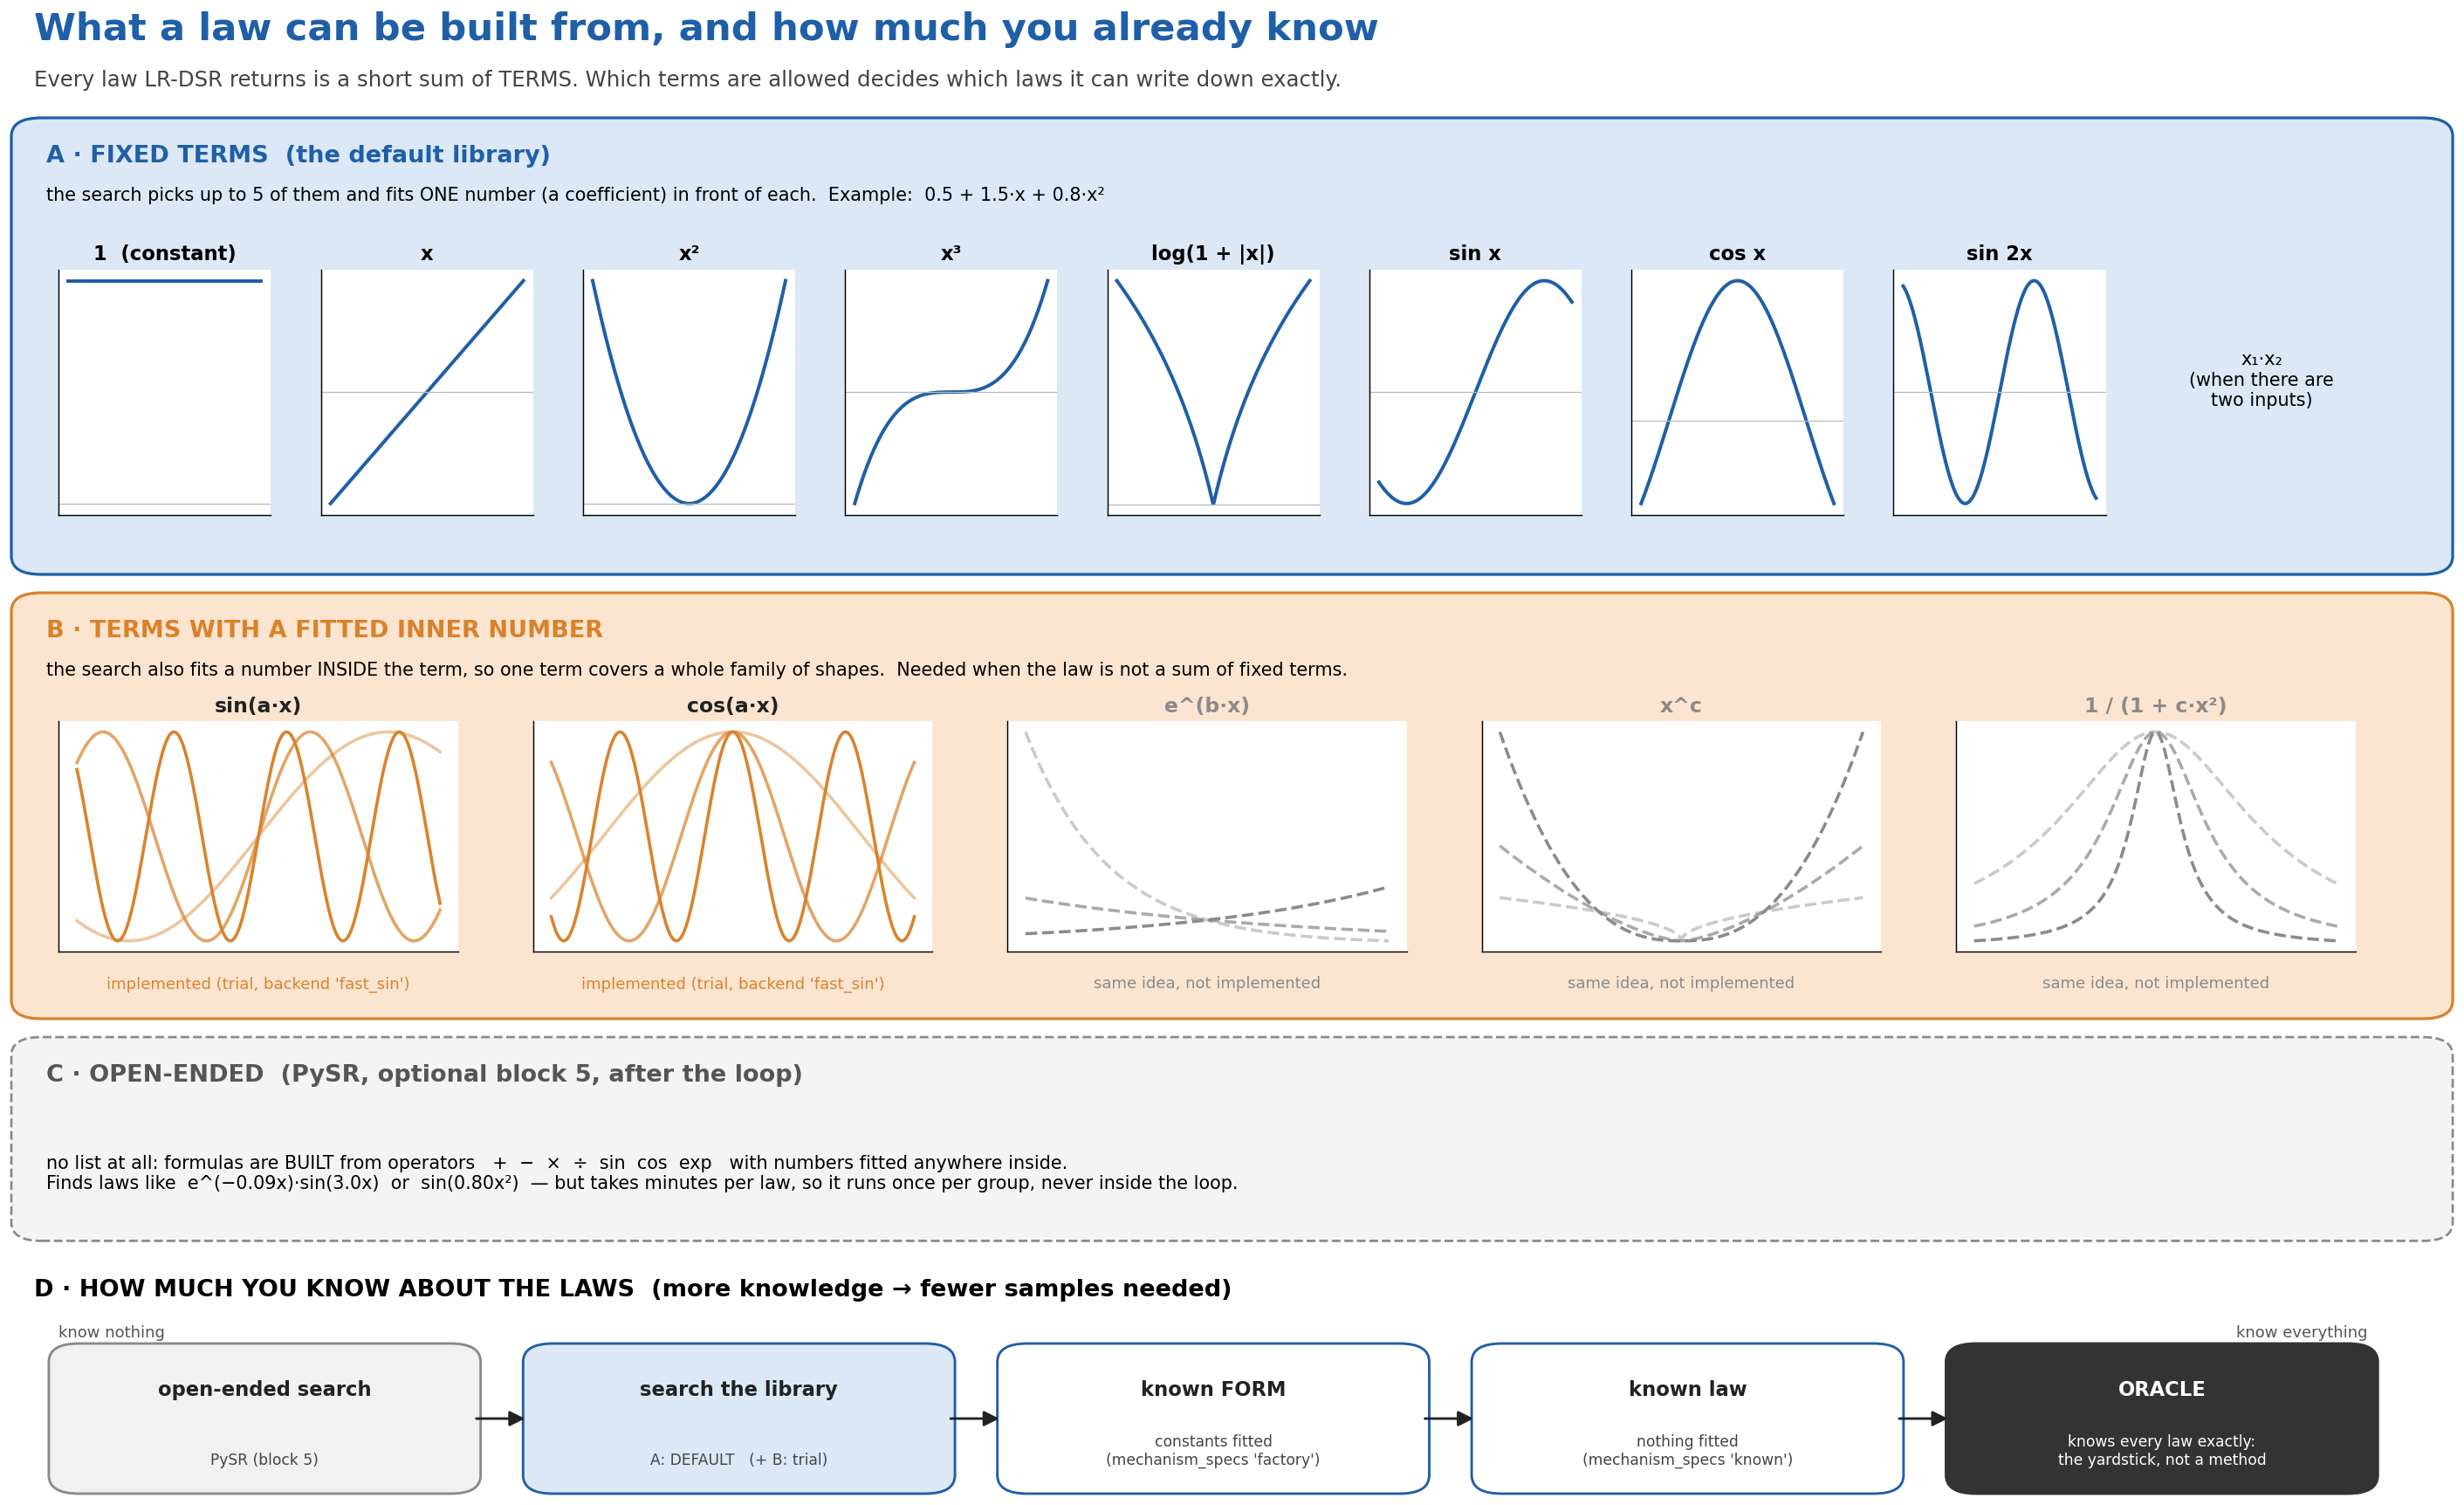

In [4]:
S.show("00_vocabulary.png")

**The objective, in one line.** Choose the labels $z$ and the laws $f$ so that
every window is explained well by its own law, with short formulas preferred:

$$
\min_{z,\,f}\;\sum_{\text{windows } w}\; \text{misfit}\big(\text{window } w,\ \text{law } f_{z_w}\big) \;+\; \text{a small cost per term}
$$

The misfit is measured in units of the noise. It uses a robust (Huber) loss,
so one outlier cannot dominate.

**How it is minimised.** Like K-means, with a *formula* in place of an average:
1. **Start:** describe each window by the coefficients of its best-fitting
   curve, and group those with K-means.
2. **Fit:** for each group, fit one short formula to all its windows together.
3. **Assign:** move every window to the formula that fits it best.
4. **Repeat** 2-3 until almost nothing moves.

**How good can anyone do?** Even the oracle mislabels some windows, because
of noise. Its error is an exact formula,
$P_{\text{err}} = Q\!\left(\sqrt{n\rho}/2\right)$: it depends only on the window
length $n$ and on how far apart the laws are, in noise units ($\rho$). Every
result below is measured against it.

---
# 3 · A worked example, live

**The task.** Three laws, 240 windows of 16 noisy points each. The true
labels are kept aside, for checking only.

**What you see.**
- **Left:** the data as you get it.
- **Middle:** the same, coloured by the hidden law.
- **Right:** the three laws to be found.

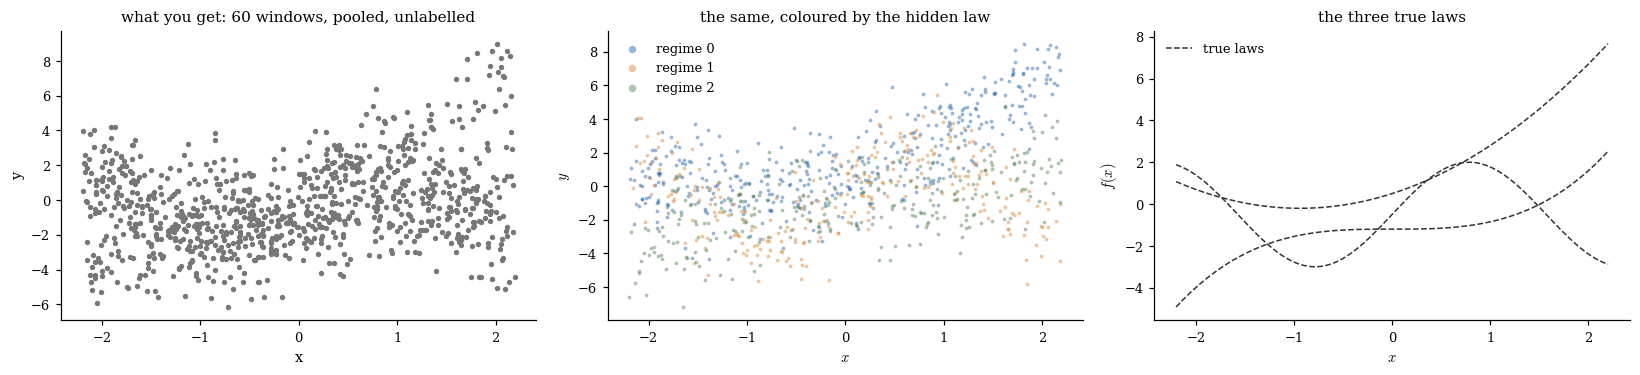

In [5]:
d = S.example()
S.example_data(d)

**Take-away.** Pooled together, the windows are a cloud; nothing in it says
"three parabola-like groups".

**The start: looks vs laws.**
- **What you see:** the same windows, coloured by their true law.
  - **Left:** placed by how they look (two summary statistics).
  - **Right:** placed by their law coefficients (*mechanism space*).
- **Take-away:** on the left the colours are mixed, and no clustering can
  separate them. On the right they form three separate groups, which K-means
  finds easily. This is why the method starts in mechanism space.

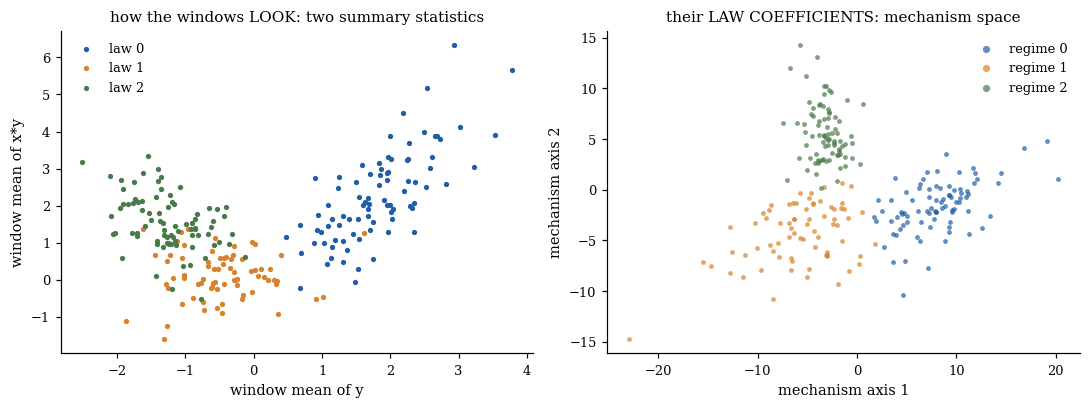

In [6]:
S.looks_vs_laws(d)

**The loop at work.**
- **The task:** to watch the loop, start it from a deliberately bad grouping.
- **What you see:** the laws fitted after 0, 1 and 2 rounds and at the end
  (solid), against the truth (dashed), with the accuracy of the grouping.
- **Take-away:** each round, the laws improve because the groups improve, and
  the groups improve because the laws improve. Here two rounds are enough.

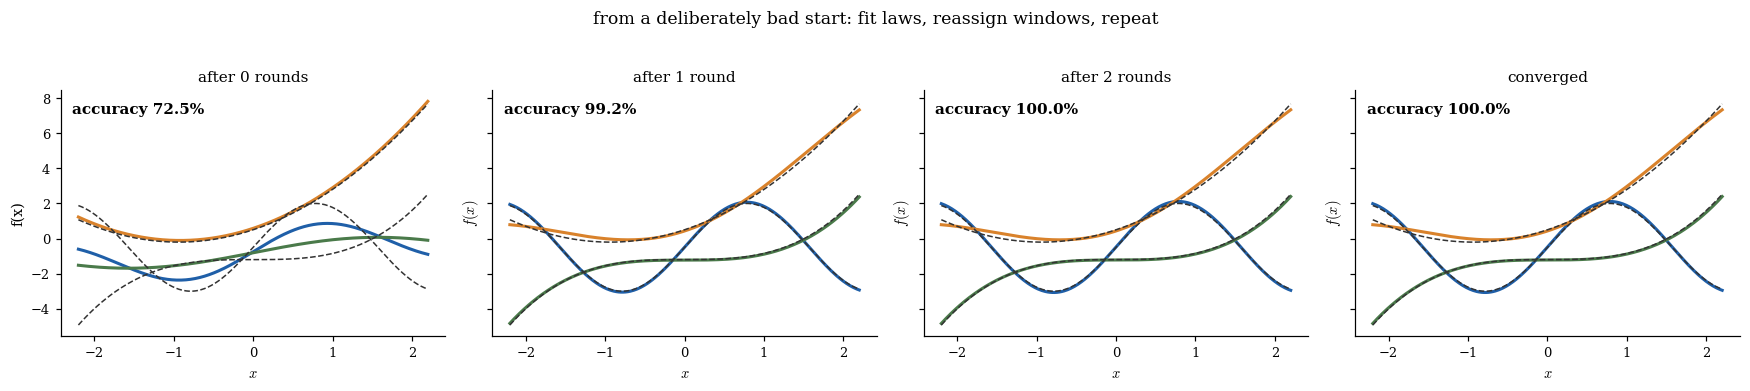

In [7]:
S.loop_rounds(d)

**The real fit** (the default settings: good start, then the loop).

**What you see.**
- **The printed laws.**
- **Left:** the laws found against the truth.
- **Second:** how one law is built. Each round tries every term (grey dots)
  and keeps the one that helps most, until none helps.
- **Third:** true law against found group. A clean diagonal means every
  window is labelled right.
- **Right:** the cost of every window under every law. The dark diagonal
  blocks mean each window is cheap only under its own law.

**Take-away.** Every window is labelled correctly. One law comes back as a
*look-alike*: the parabola is written with $\cos x$. On this range it is the
same curve, but it is not the same formula; that is the price of a fixed
term library.

accuracy 100.0%, in 2 rounds
   law 0:  y = 2.7175 +1.4884*x -2.2863*cos(x)
   law 1:  y = -1.2222 +0.33956*(x)^3
   law 2:  y = -0.48016 +2.5939*sin(2*x)


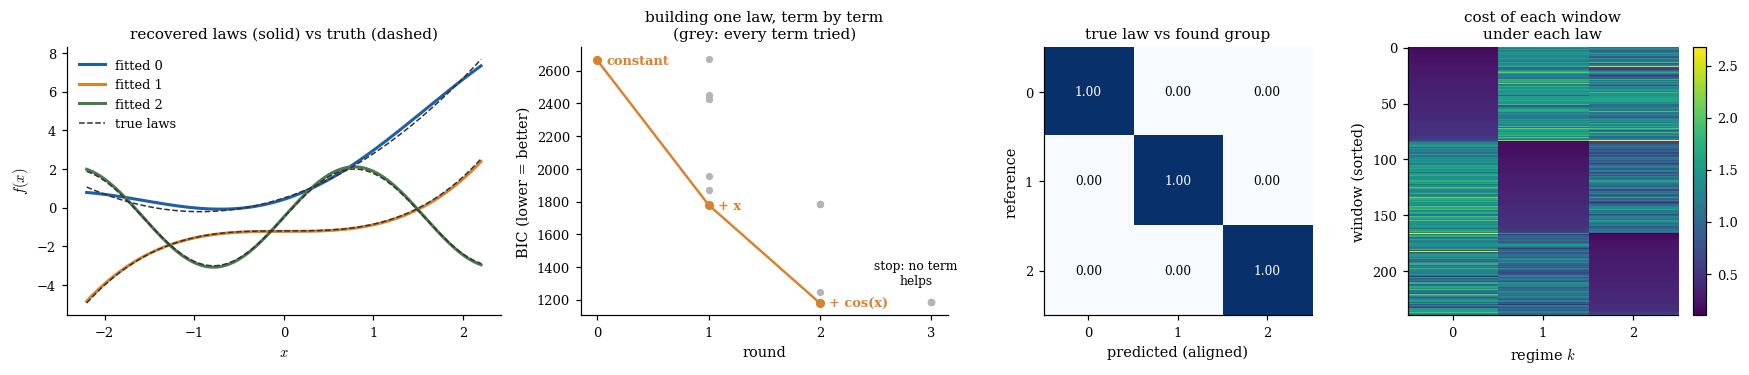

In [8]:
S.the_fit(d)

**The soft version** gives each window a *probability* for each law, rather
than one label.

**What you see.**
- **Left:** the laws it finds.
- **Right:** one column per window, coloured by its probabilities. A column of
  one solid colour means the method is sure.

**Take-away.** Almost every window is certain; the few mixed columns are the
genuinely ambiguous windows.

accuracy 100.0%;  1.2% of windows are less than 90% sure


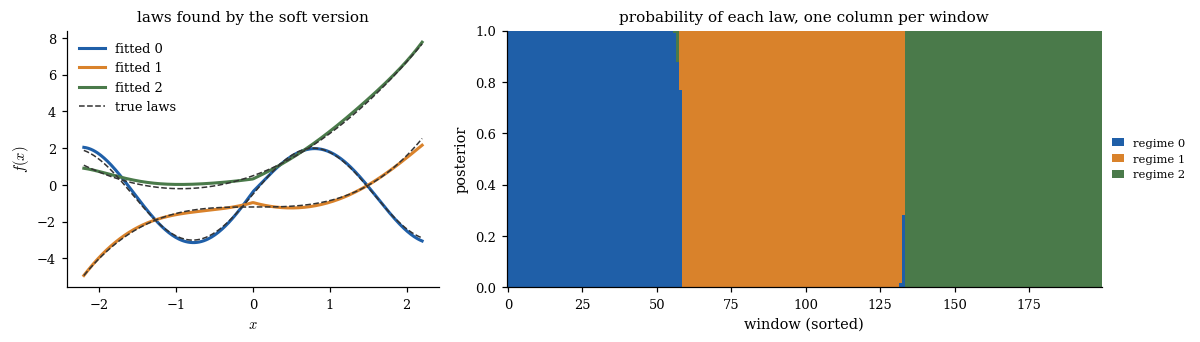

In [9]:
S.soft_version(d)

**How close to the best possible?**
- **The task:** make the problem harder by adding noise, and compare three
  things: the oracle (knows the laws), the method (knows nothing), and the
  usual look-alike clustering.
- **What you see:** accuracy at four noise levels.
- **Take-away:** the method stays with the oracle at every noise level. The
  look-alike clustering falls towards chance.

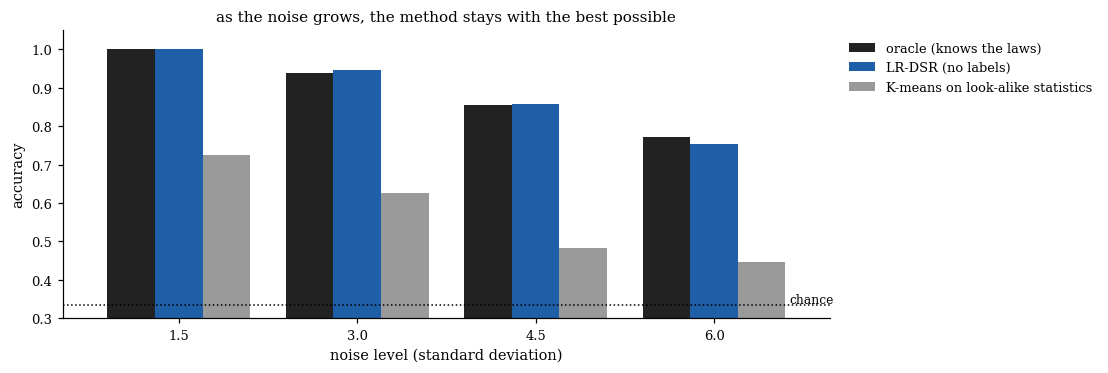

In [10]:
S.noise_sweep()

**What is the loop for? An honest note.**
- **The task:** hand the loop starting groupings of different quality, and
  measure what it returns.
- **What you see:**
  - **Left:** how much the loop repairs, against how broken the start was.
  - **Middle:** error in against error out.
  - **Right:** the usual starting methods, before and after the loop.
- **Take-away:** the loop returns about the same answer whatever it is given.
  It **repairs bad starts** a lot, but it does not improve a good one (right,
  last pair). The *start* does most of the work; the loop makes the method
  robust, and produces the formulas.

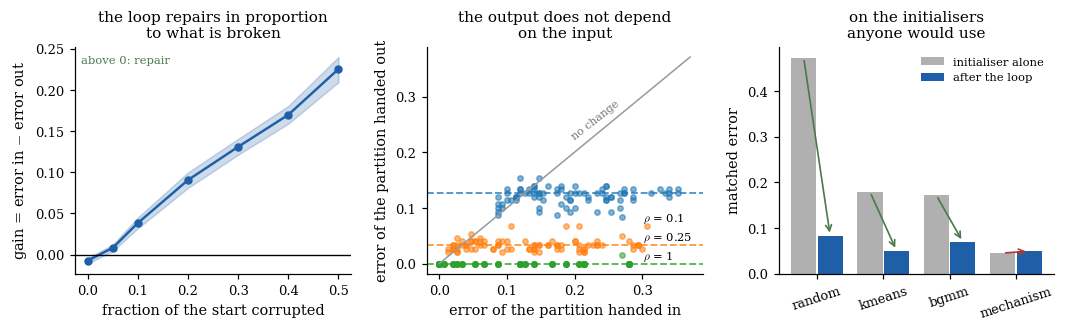

In [11]:
S.result("loop_value")

---
# 4 · What works

All figures in this part are read from the committed results.

### The best possible error is reachable without labels

- **The task:** is the formula for the best possible error right, and can the
  method reach it without labels?
- **What you see:**
  - **Left:** the method's start (K-means in mechanism space) against the exact
    best possible error, in many settings. The points lie on the diagonal.
  - **Right:** the same, when all laws share a large common part. The result
    does not change.
- **Take-away:** without any labels, the method reaches the best possible
  error, and a part that all laws share does not disturb it.

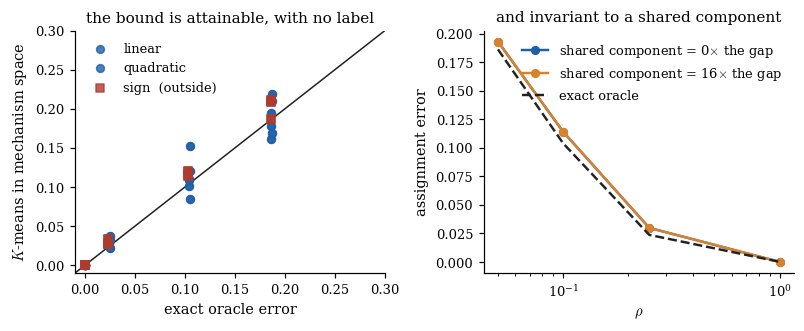

In [12]:
S.result("attainability")

### Outliers in the noise

- **The task:** real noise has outliers. Which way of measuring misfit keeps
  the method near the best possible?
- **What you see:** the error under four kinds of noise, from normal (left) to
  10% gross outliers (right), for each loss. Black is the best possible.
- **Take-away:** with normal noise, every loss is fine. With heavy tails, the
  squared loss (and the normal-noise soft version, pink) fail badly, while
  Huber and the **learned** loss (which fits the noise shape as it goes) stay
  at the best possible.

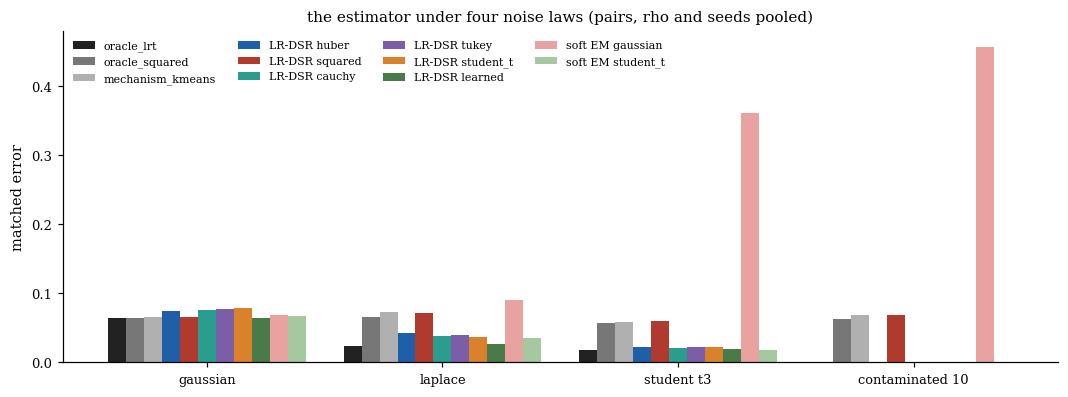

In [13]:
S.result("loss_estimator")

### Real time: when does a switch get noticed?

- **The task:** in one long stream that switches between laws, how long after
  a switch does the method notice it, and how often does it raise false alarms?
- **What you see:**
  - **Left:** delay after a switch, measured (dots) against the prediction (lines).
  - **Right:** time between false alarms, which always stays above the
    guaranteed bound (dashed).
- **Take-away:** the delay is predicted by a formula before running anything,
  and false alarms are as rare as promised.

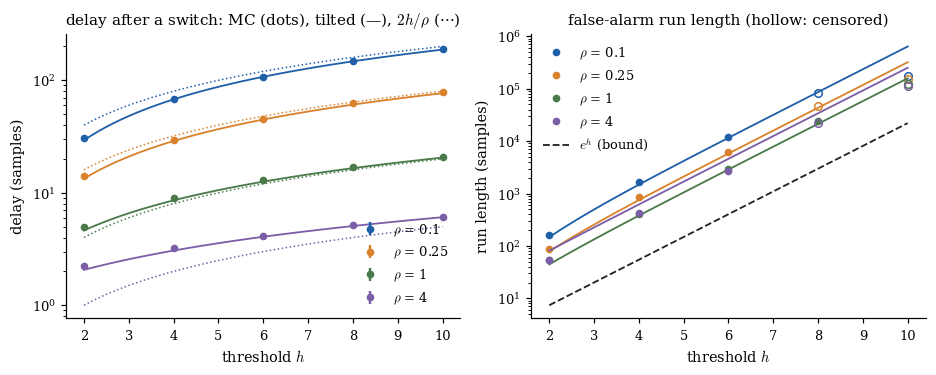

In [14]:
S.result("online_sequential")

### Days with missing hours

- **The task:** many real traffic days have sensor gaps. The usual fix is to
  fill in the missing hours, then classify. Can the law do better, using only
  the hours observed?
- **What you see:** the share of days labelled correctly, against how many
  hours were observed.
  - **Left:** real days with gaps.
  - **Right:** complete days with real gap patterns cut out.
  - **Blue:** the law; **orange and black:** two ways of filling in.
- **Take-away:** with long gaps (6-11 of 24 hours observed), the law labels
  every real day correctly (99% in the controlled version), while filling in
  gets many wrong. With few hours missing, all
  methods agree.

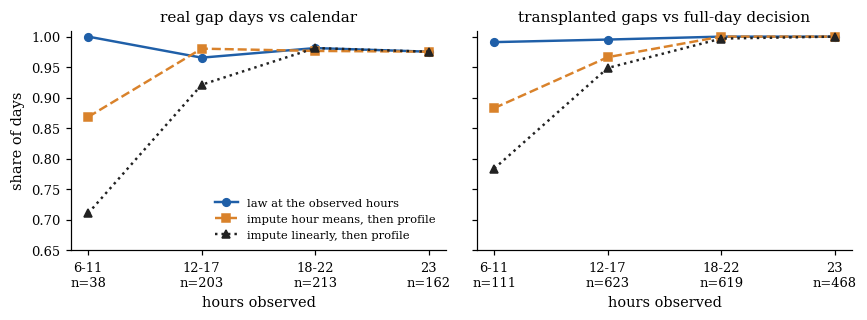

In [15]:
S.result("realdata_gaps")

### A new law appears in a stream

- **The task:** a law that was never seen before starts appearing in a stream.
  Does the real-time version notice, and create a new group for it?
- **What you see:** the share of streams in which the new law got its own group.
  - **Blue:** with a flexible (kernel) basis.
  - **Orange:** with the fixed term library.
  - **Dotted:** what an ideal test could do.
- **Take-away:** with a flexible basis the new law is found; with the fixed
  library it is mostly missed, because the library cannot describe it.

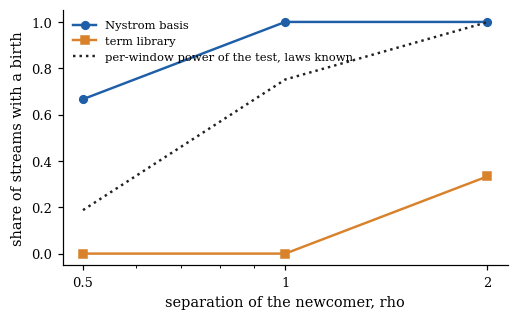

In [16]:
S.result("online_kernel_birth")

### Classification: how many labelled examples are enough?

- **The task:** when some labelled windows exist, how does the error fall as
  more are added, and can that be predicted?
- **What you see:** classification error against the number of labelled
  windows per class. Markers are measured; lines are the formula; grey is the
  best possible. Each line style is a different law size.
- **Take-away:** the formula predicts the whole learning curve. It depends on
  how many coefficients a law has, not on the window length.

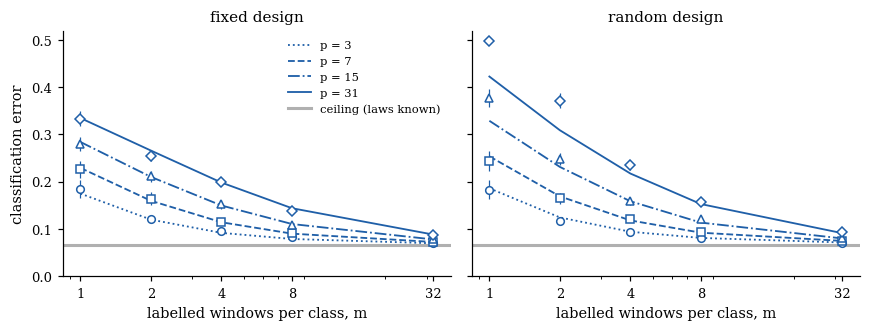

In [17]:
S.result("v10_learning_curve")

### Wind turbines: every window sees different inputs

This is the method's home ground. Each 6-hour block of a turbine sees
different wind speeds, so there is no common "profile" to compare.

- **The task:** can the law tell cold air from warm, and a turbine in another
  turbine's wake from one in free wind, on turbines never trained on?
- **What you see:**
  - **Top:** error per question (lower is better). Blue is the law; the
    others are the industry's binned-curve method; red dashes are the best
    possible. "Night vs day" is a control that should show nothing.
  - **Bottom:** how much more power a turbine makes in cold air than in warm
    air, at each wind speed. The grey line is the physics prediction (air
    density).
- **Take-away:** the law beats the industry method on both real questions,
  while on the control every method stays near chance, as it should. The measured power ratio settles onto the
  physics prediction, so the laws found are physically meaningful.

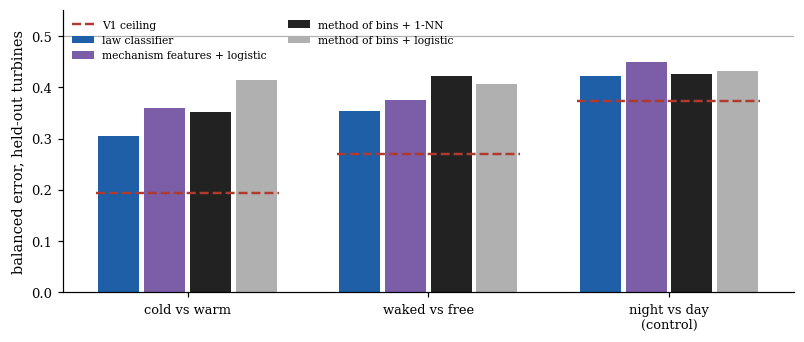

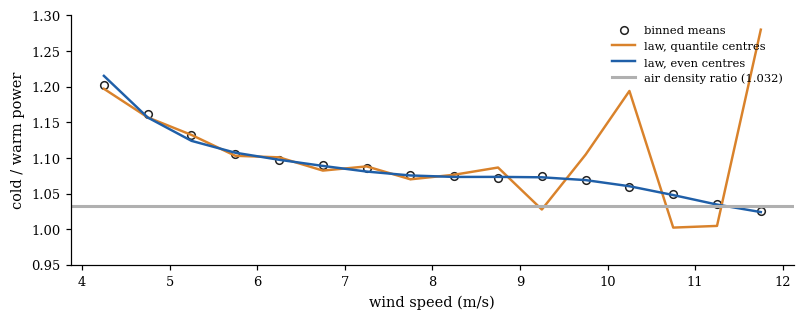

In [18]:
S.result("wind_transfer")
S.result("wind_physics")

### Is this better than plain symbolic regression?

- **The task:** compare with the same formula search used the usual way:
  either one formula for all windows, or one formula per window, clustered
  afterwards.
- **What you see:**
  - **Left:** share of windows labelled wrong.
  - **Right:** how far the formulas found are from the true ones.
  - Both are shown against how far apart the laws are.
- **Take-away:** one formula for everything is at chance. One formula per
  window is much worse than LR-DSR when the data are noisy, because 16 noisy
  points are too few to pin down a formula. Pooling the windows of a group is
  what makes the laws accurate.

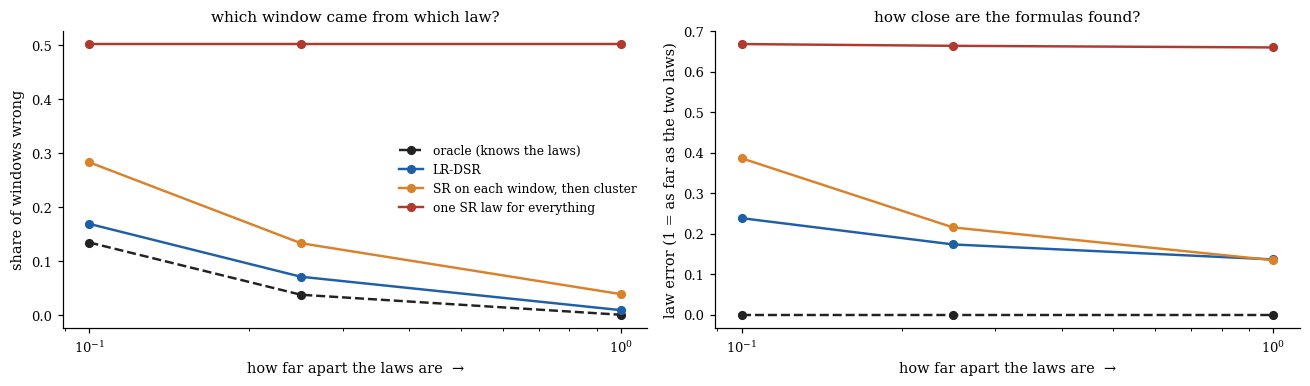

In [19]:
S.sr_baseline()

---
# 5 · Real data: two years of bike sharing

**The task.** Washington DC bike rentals, one window per day, with the hour
of the day as input. The method gets no labels and is asked for two laws.
Afterwards we compare with the calendar (working day or not). The calendar is
a proxy, not the truth.

723 days;  agreement with the calendar: 98.6%


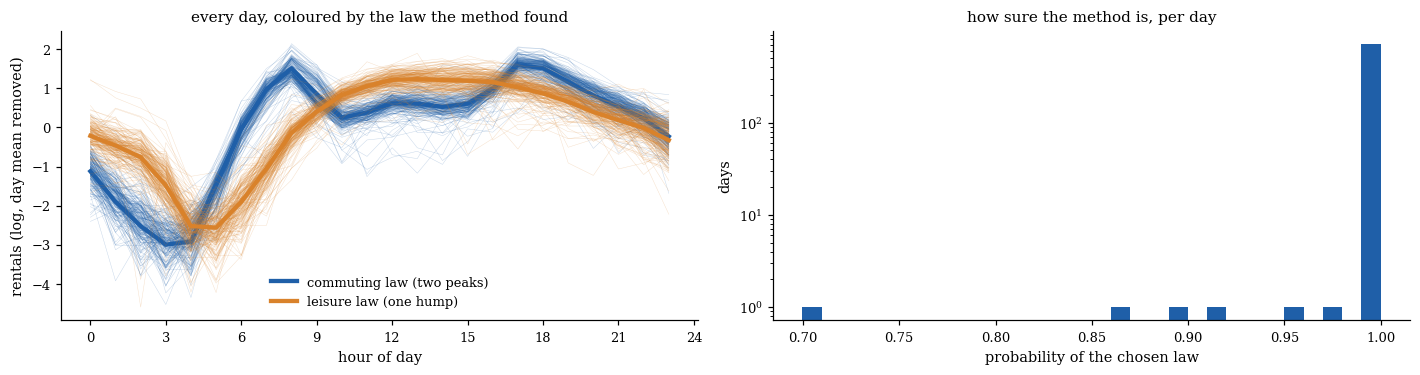

In [20]:
bk = S.bike()
S.bike_days(bk)

**What you see.**
- **Left:** every day, coloured by the law the method found. The two shapes
  are a commuting day (morning and evening peaks) and a leisure day (one
  afternoon hump).
- **Right:** how sure the method is; almost every day is certain.

**Take-away.** The two laws are exactly the two kinds of days, found without
being told what a weekend is.

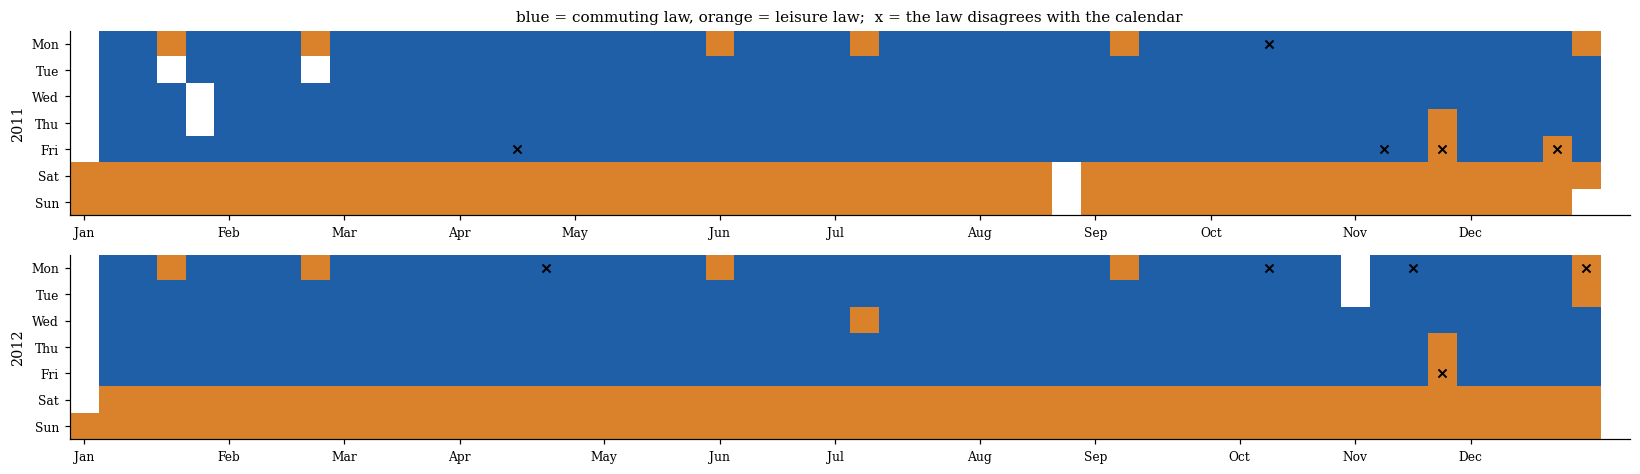

In [21]:
S.bike_calendar(bk)

**What you see.** The same labels on a calendar: weeks across, weekdays down.
Crosses mark days where the law and the calendar disagree.

**Take-away.** Weekends and big holidays are found. The disagreements are of
two kinds:
- **official holidays most people still work** (Columbus Day, Veterans Day):
  the law says *commuting*;
- **days off the calendar does not know about** (the Friday after
  Thanksgiving, Christmas Eve): the law says *leisure*.

In both cases the law is arguably right, and the calendar wrong.

---
# 6 · What did not work

### Failure 1: a law the library cannot write, and a trial fix

**The task.** Two fast oscillations, $\sin 4x$ and $\sin 4.6x$. The library's
fastest term is $\sin 2x$, so it cannot write them. The trial fix adds terms
$\sin(a\,x)$, $\cos(a\,x)$ with the number $a$ fitted. Every method runs on the
same windows, at two noise levels.

**What you see.**
- **Top:** the true laws; what LR-DSR finds with the standard library
  (look-alikes); what it finds with the fitted frequency (the true laws).
- **Middle:** accuracy of every method, on noisy and on clean windows. Black
  is the best possible; blue is this project's methods; orange is the
  signal-processing standard (periodogram); green is plain symbolic regression
  per window; grey is clustering the raw data.
- **Bottom:** why the standard methods fail in noise. A single window's
  spectrum is broad and its peak wanders; the method fits one frequency to all
  of a group's windows at once (blue lines).

LR-DSR, standard library:  y = -0.0067717 -0.19618*sin(x) +0.10578*sin(2*x)   |   y = -0.010483 -0.11872*(x)^3 +0.48718*x -0.5199*sin(2*x)
LR-DSR, + fitted frequency:  y = 0.015131 +1.0431*sin(4.58*x)   |   y = -0.031101 +0.9956*sin(3.968*x)


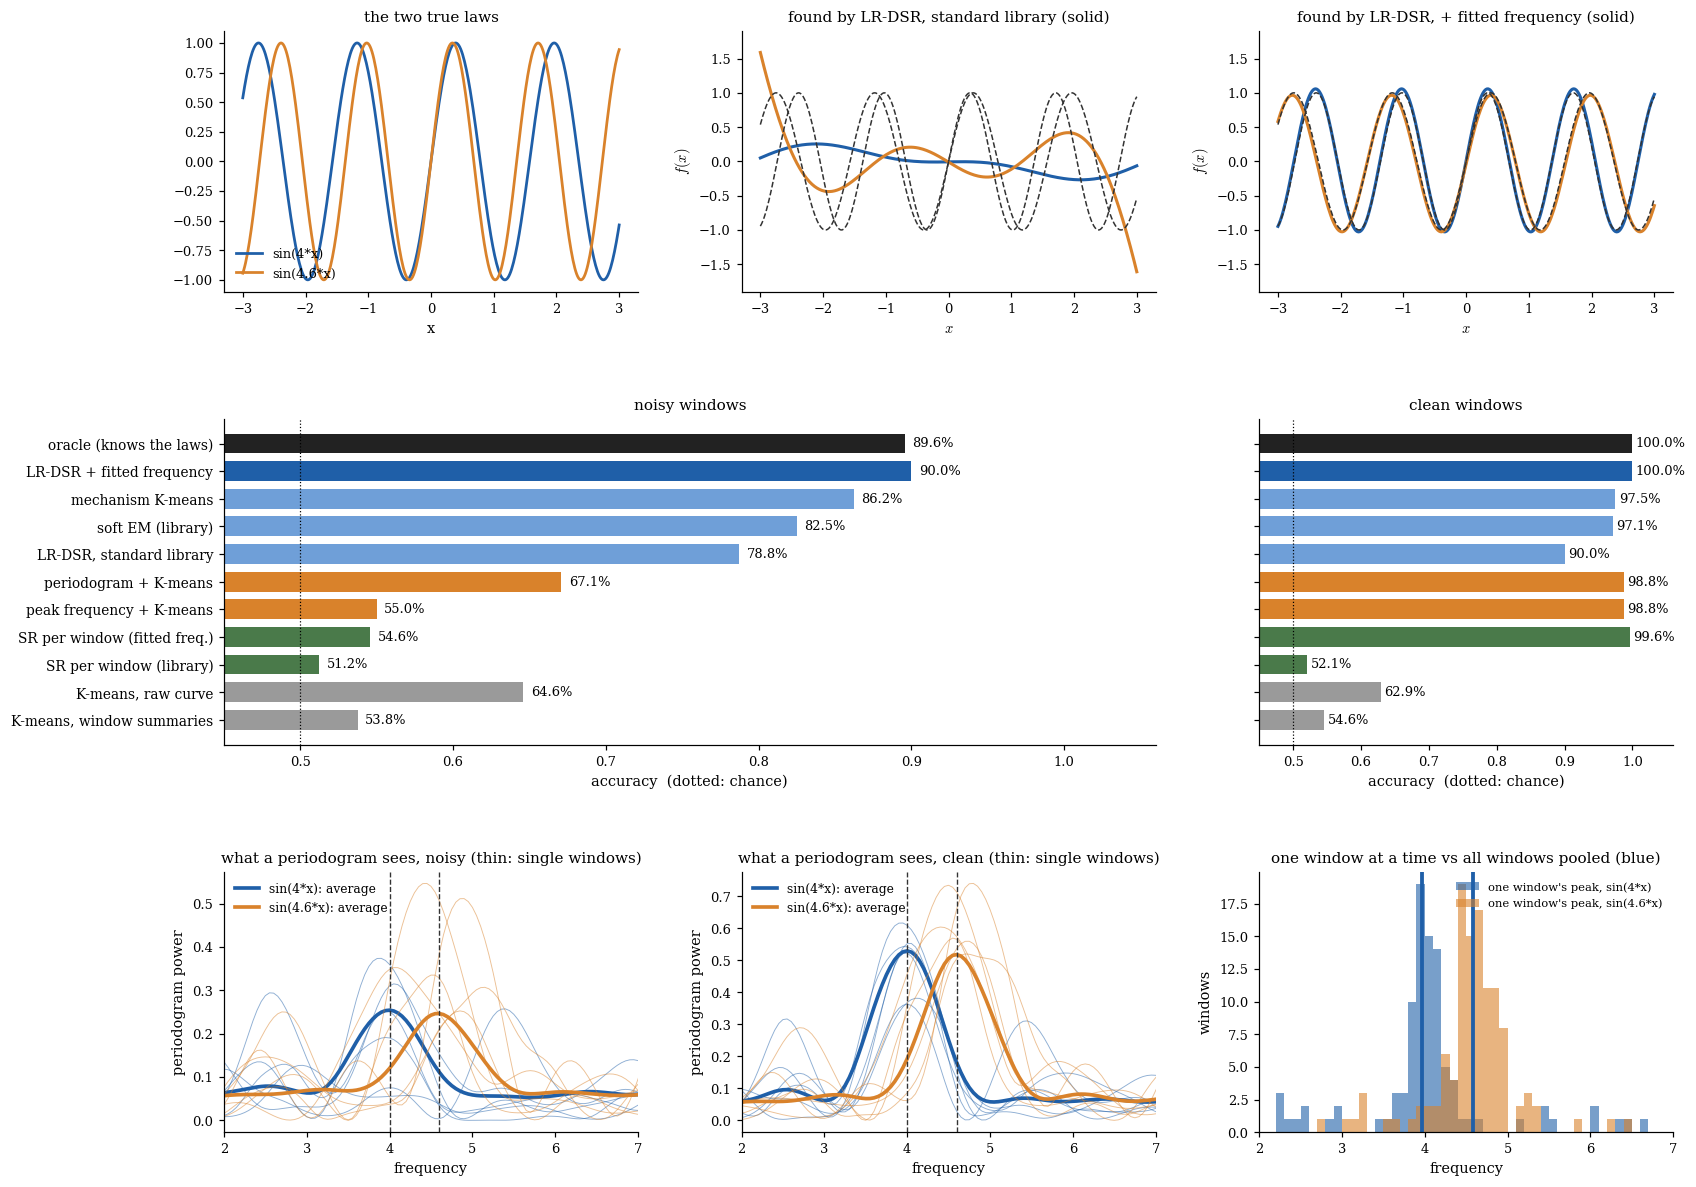

In [22]:
S.fast_oscillations()

**Take-away.**
- With the standard library, the method is clearly behind the best possible.
- With the fitted frequency, it reaches the best possible, even in noise.
- On clean data the standard methods also solve it; in noise only the methods
  that **pool windows** get close.

**Does the extra freedom hurt the problems that did not need it?**
- **What you see:** all twelve test problems, standard library against
  fitted frequency.
- **Take-away:** only the fast oscillation changes; nothing else gets worse.

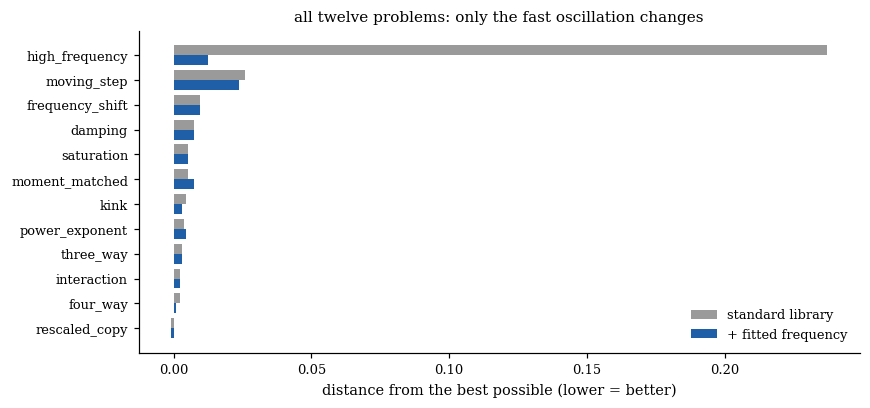

In [23]:
S.fitted_frequency_zoo()

### Failure 2: against strong classifiers on 24 standard datasets

- **The task:** on 24 public classification benchmarks, compare the best law
  classifier with the best standard classifier on the raw series.
- **What you see:** one point per dataset. Horizontal: the law's error;
  vertical: the raw classifier's error. Points **below** the diagonal are
  datasets where the raw classifier wins.
- **Take-away:** most points are below or on the diagonal. When every series
  has the same complete inputs, a well-tuned standard classifier is hard to
  beat. The method's edge is where inputs differ between windows (gaps, wind),
  not here.

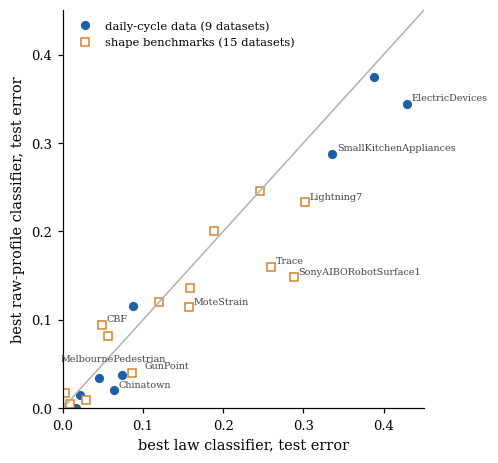

In [24]:
S.result("classify_benchmark")

### Failure 3: noise that wanders over time

**The task.** The method assumes the noise is independent from one sample to
the next, like fresh coin flips. Real noise often wanders: once it is above
the curve, it stays above for a while. How much does the method lose when
that assumption breaks?

**What you see.** The same law and the same noise size, with the noise
wandering more from left to right.

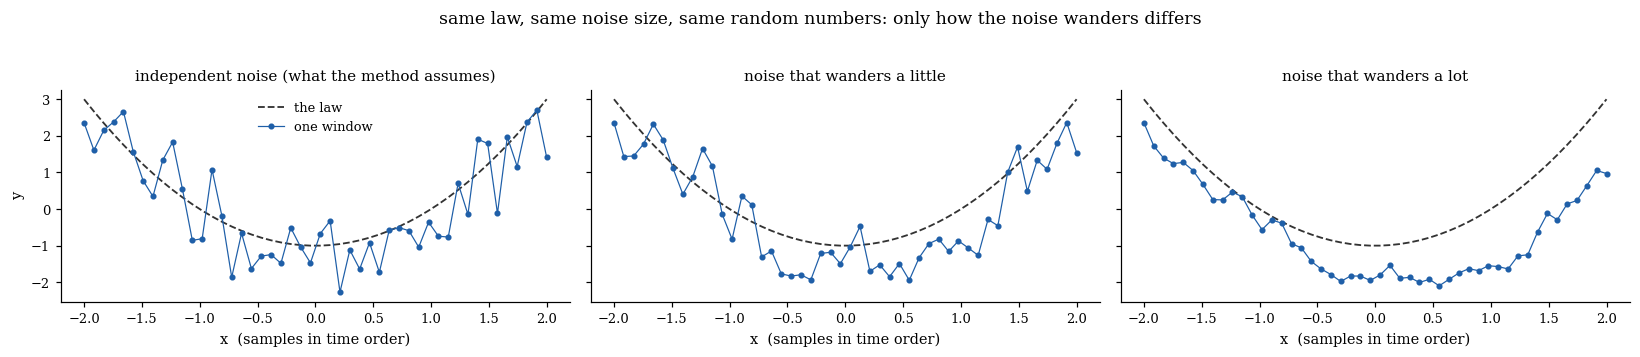

In [25]:
S.correlated_noise_intuition()

**What you see next.** Accuracy as the noise wanders more.
- **Black:** the best possible *for this kind of rule*.
- **Blue:** the method.
- **Red area:** the gap between them.
- **Dashed:** a rule that knows how the noise wanders.
- **Green band:** how much the noise wanders on real days.

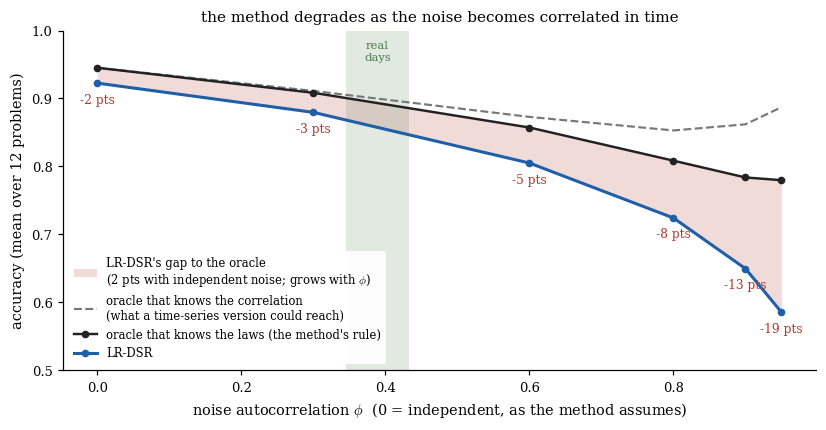

In [26]:
S.result("robustness_failure")

**Take-away.**
- At the level of wandering seen on real days, the method loses very little.
- With strongly wandering noise it falls clearly behind.
- The dashed curve shows that a rule aware of the wandering would do much
  better. That is the natural next improvement: "whiten" the noise inside the
  loop.

### The other negatives, kept in view

- The number of laws must be given. Choosing it automatically (by BIC) fails
  on real days.
- The formula for a partial day's error ranks which hours matter correctly,
  but its absolute level is off by a factor of a few.
- Scattered missing samples give no advantage; only *long* gaps do.
- Wind: one of two predictions made before the run failed. Clustering wind
  blocks without labels matches no physical cause.

---
# 7 · Every task in one picture

Sixteen questions, one panel each. **The frame colour is the answer**:
**green** = yes, **amber** = partly. Blue bars are this method, grey bars the
alternative (or the situation before), and black bars the best possible or a
prediction. Lower is better unless the panel says otherwise.

| # | the question | what the bars compare |
|---|---|---|
| 1 | Is there a best possible error, as a formula? | share of settings where formula and measurement agree |
| 2 | Can it be reached without labels? | best possible vs our start vs LR-DSR vs look-alike clustering |
| 3 | What does the loop add? | error of a starting grouping, before and after the loop |
| 4 | Does it work on twelve hard problems? | average distance from the best possible, per method |
| 5 | Does it survive outliers? | best possible vs robust losses vs the squared loss |
| 6 | Are switches seen in real time, as predicted? | predicted vs measured delay |
| 7 | Real days: weekday vs weekend? | agreement with the calendar |
| 8 | Days with long sensor gaps? | the law vs filling in the gaps |
| 9 | Can a partial day's error be predicted? | predicted vs measured (timing right, level off) |
| 10 | A law the library cannot write? | fixed library vs flexible kernel basis |
| 11 | Can the classification error be predicted? | share of settings where formula and measurement agree |
| 12 | 24 standard classification datasets? | law vs nearest raw series vs best tuned classifier |
| 13 | Repair: series shifted in time? | law, law with a time shift, the time-warping standard |
| 14 | Streaming days with gaps? | accuracy on partial vs complete days |
| 15 | Wind: cold vs warm air? | best possible vs law vs the industry method |
| 16 | Better than plain symbolic regression? | best possible vs LR-DSR vs SR per window vs one SR law |

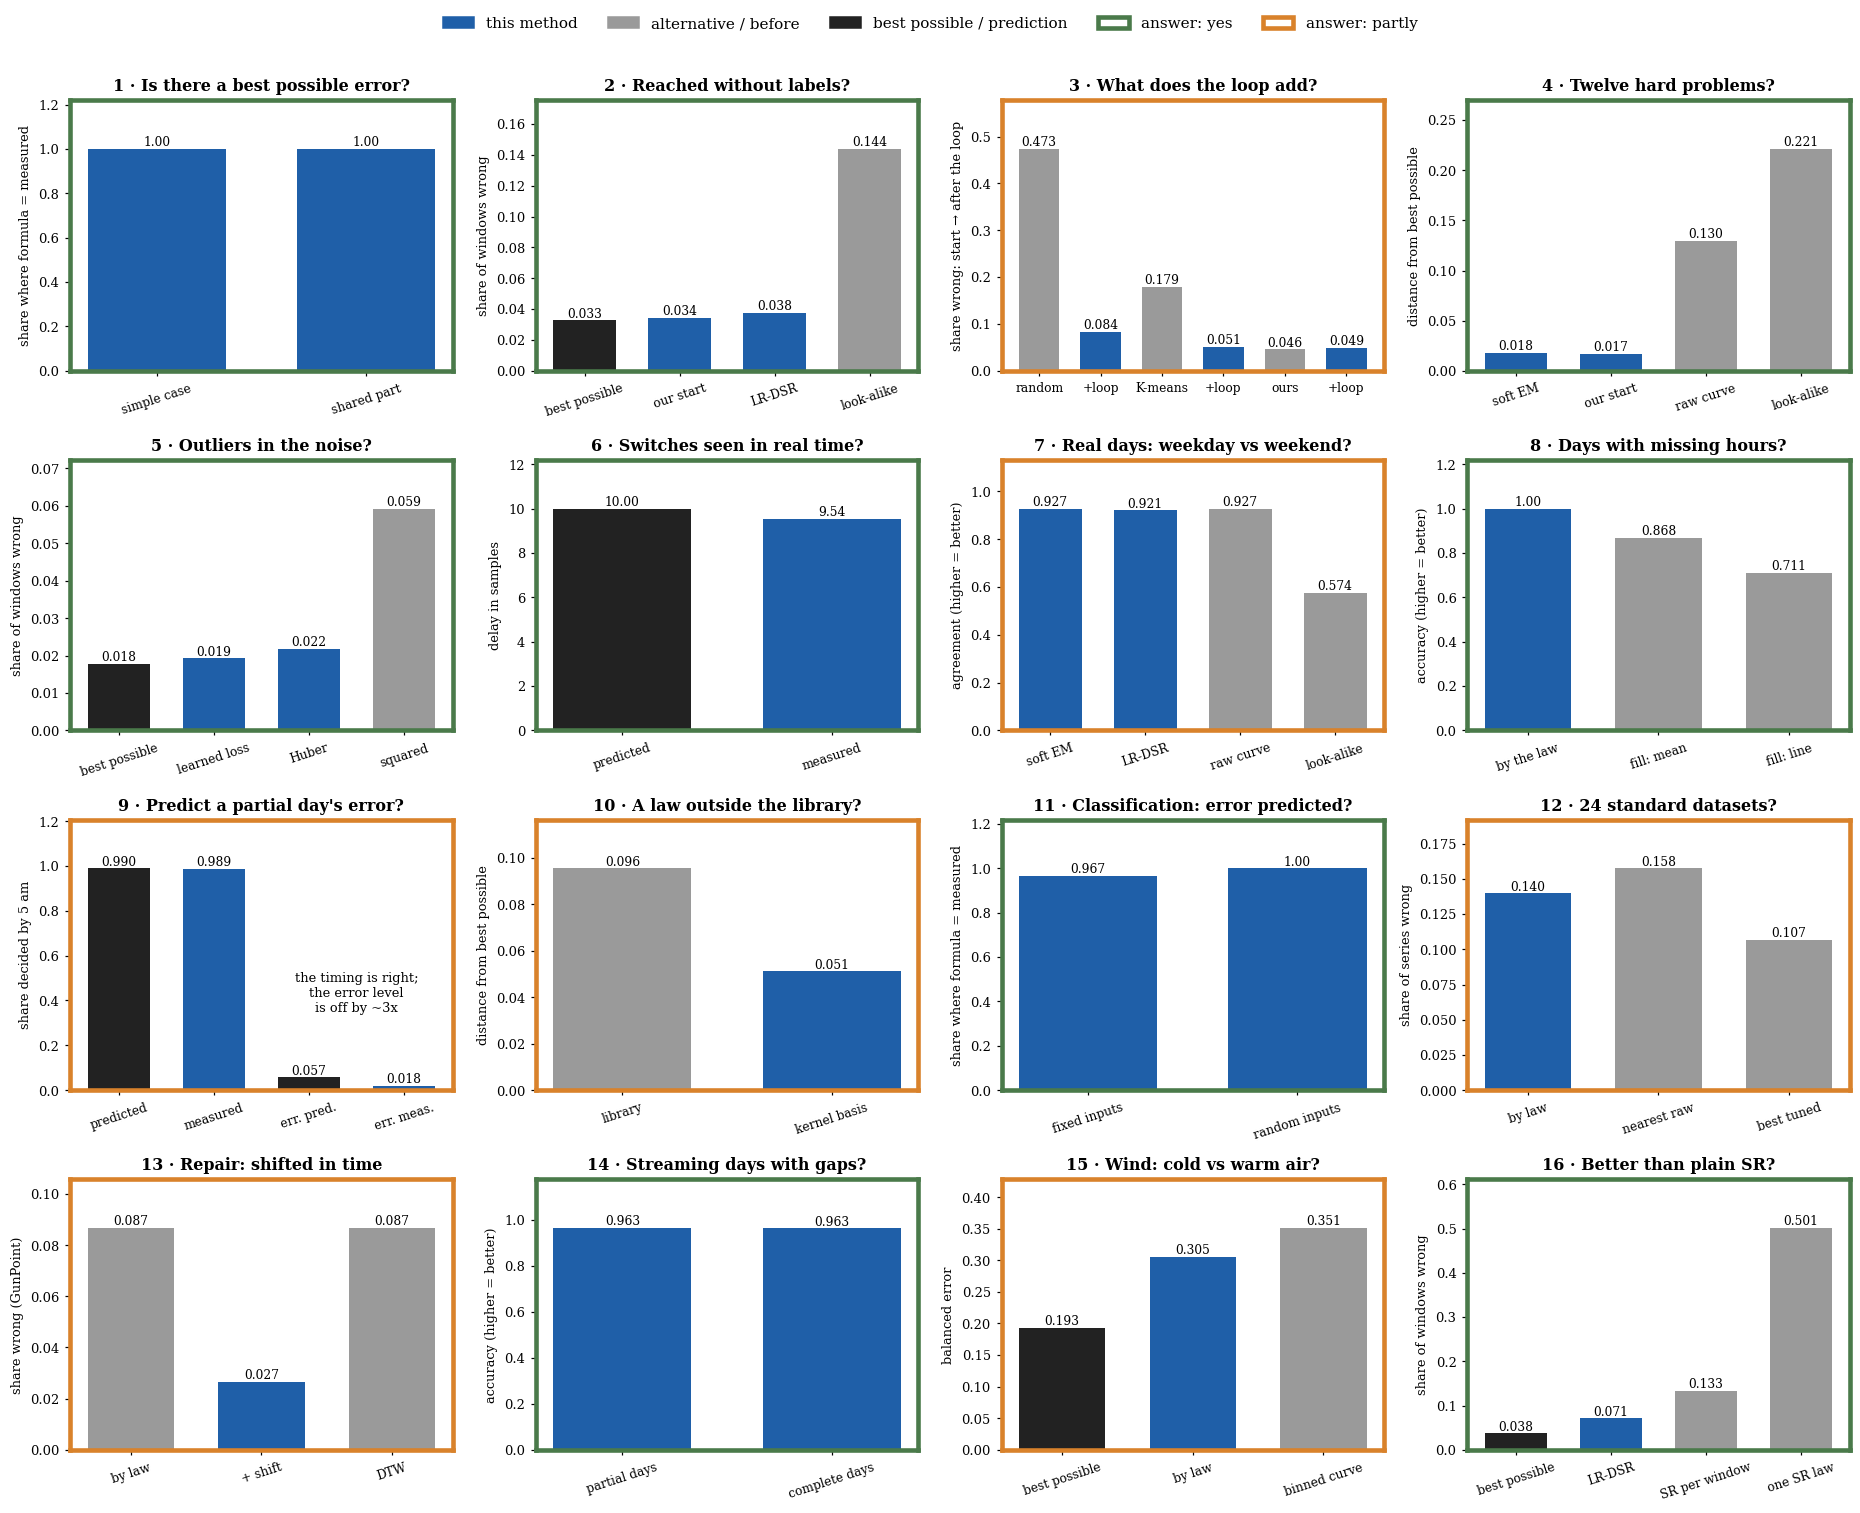

In [27]:
S.scorecard()

## Take-aways

1. **Grouping windows by their law is a well-posed problem, with a known best
   possible error, and the method reaches it without labels.** The start does
   most of the work; the loop makes it robust and produces readable laws.
2. **It wins where the inputs differ from window to window:** days with long
   sensor gaps, wind turbines at different wind speeds, a new law in a stream,
   noisy oscillations. When every window has the same complete inputs, a good
   standard method ties it or beats it.
3. **It beats plain symbolic regression.** One formula per window is too noisy
   and one formula for everything is wrong; pooling a group's windows is what
   makes the laws accurate.
4. **Its limits are known:**
   - the library (a law it cannot write costs accuracy, and a fitted-number
     term or a kernel basis fixes that);
   - noise that wanders over time;
   - the number of laws must be given.

**Where next:**
- `09_algorithm_tutorial`: every block by hand, with all options.
- `01_quickstart`: the API on your own data.
- Notebooks 02-08 go deeper into each part.
- `RESULTS.md` has every number.